In [1]:
import pandas as pd
import numpy as np

# Create 2 years of historical sales data
np.random.seed(42)

dates = pd.date_range(start='2024-01-01', end='2025-12-31', freq='D')

# Generate realistic sales with trend + seasonality + random variation
trend = np.linspace(1000, 1800, len(dates))
seasonality = 200 * np.sin(np.arange(len(dates)) * 2 * np.pi / 365)
noise = np.random.normal(0, 100, len(dates))

sales = trend + seasonality + noise
sales = np.maximum(sales, 100).round(2)

df = pd.DataFrame({
    'Date': dates,
    'Sales': sales
})

# Add a few missing values for preprocessing demonstration
df.loc[[50, 150, 300], 'Sales'] = np.nan

# Save dataset
df.to_csv('historical_sales.csv', index=False)

print("Dataset created successfully!")
print(df.head())
print("\nDataset shape:", df.shape)

Dataset created successfully!
        Date    Sales
0 2024-01-01  1049.67
1 2024-01-02   990.71
2 2024-01-03  1073.84
3 2024-01-04  1165.91
4 2024-01-05   994.73

Dataset shape: (731, 2)


In [2]:
# Check missing values
print(df.isnull().sum())

# Fill missing sales values
df['Sales'] = df['Sales'].interpolate()

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Date     0
Sales    3
dtype: int64

Missing values after cleaning:
Date     0
Sales    0
dtype: int64


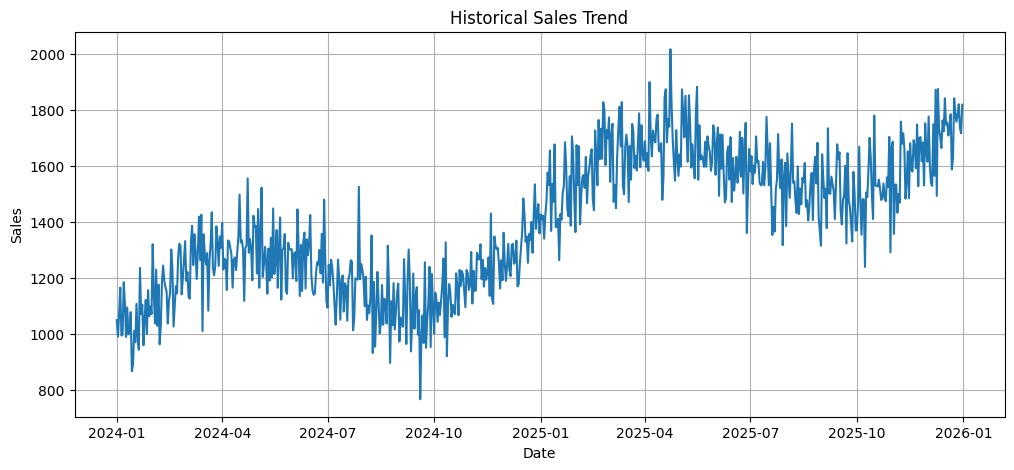

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Sales'])

plt.title('Historical Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid()
plt.show()

Create prediction features

In [4]:
# Create time-based features
df['Day_Number'] = np.arange(len(df))
df['DayOfYear'] = df['Date'].dt.dayofyear

# Seasonal features
df['Sin_Season'] = np.sin(2 * np.pi * df['DayOfYear'] / 365)
df['Cos_Season'] = np.cos(2 * np.pi * df['DayOfYear'] / 365)

df.head()

,Date,Sales,Day_Number,DayOfYear,Sin_Season,Cos_Season
0,2024-01-01,1049.67,0,1,0.017213,0.999852
1,2024-01-02,990.71,1,2,0.034422,0.999407
2,2024-01-03,1073.84,2,3,0.051620,0.998667
3,2024-01-04,1165.91,3,4,0.068802,0.997630
4,2024-01-05,994.73,4,5,0.085965,0.996298


Train the predictive model

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features and target
X = df[['Day_Number', 'Sin_Season', 'Cos_Season']]
y = df['Sales']

# Use the first 80% for training and last 20% for testing
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


Check model accuracy

In [7]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R² Score:", round(r2, 4))

Mean Absolute Error: 78.41
Root Mean Squared Error: 99.46
R² Score: 0.4373


Actual vs Predicted graph

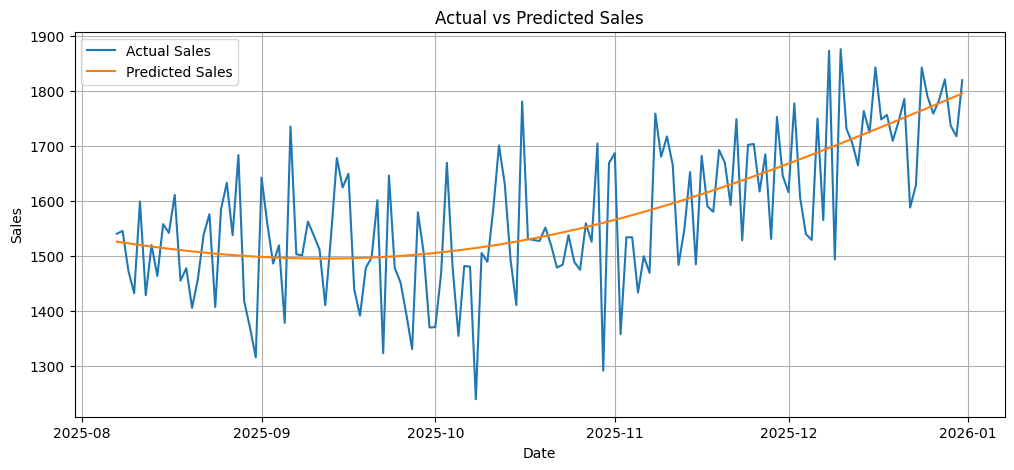

In [6]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'].iloc[split:], y_test.values, label='Actual Sales')
plt.plot(df['Date'].iloc[split:], y_pred, label='Predicted Sales')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()

plt.show()

Predict the next 30 days

In [8]:
future_dates = pd.date_range(
    start=df['Date'].max() + pd.Timedelta(days=1),
    periods=30
)

future = pd.DataFrame({'Date': future_dates})

future['Day_Number'] = np.arange(
    len(df), len(df) + 30
)

future['DayOfYear'] = future['Date'].dt.dayofyear

future['Sin_Season'] = np.sin(
    2 * np.pi * future['DayOfYear'] / 365
)

future['Cos_Season'] = np.cos(
    2 * np.pi * future['DayOfYear'] / 365
)

future['Predicted_Sales'] = model.predict(
    future[['Day_Number', 'Sin_Season', 'Cos_Season']]
)

future.head(10)

,Date,Day_Number,DayOfYear,Sin_Season,Cos_Season,Predicted_Sales
0,2026-01-01,731,1,0.017213,0.999852,1799.805416
1,2026-01-02,732,2,0.034422,0.999407,1804.201116
2,2026-01-03,733,3,0.051620,0.998667,1808.595296
3,2026-01-04,734,4,0.068802,0.997630,1812.986978
4,2026-01-05,735,5,0.085965,0.996298,1817.375183
5,2026-01-06,736,6,0.103102,0.994671,1821.758933
6,2026-01-07,737,7,0.120208,0.992749,1826.137251
7,2026-01-08,738,8,0.137279,0.990532,1830.509164
8,2026-01-09,739,9,0.154309,0.988023,1834.873697
9,2026-01-10,740,10,0.171293,0.985220,1839.229880


FINAL FORECAST GRAPH

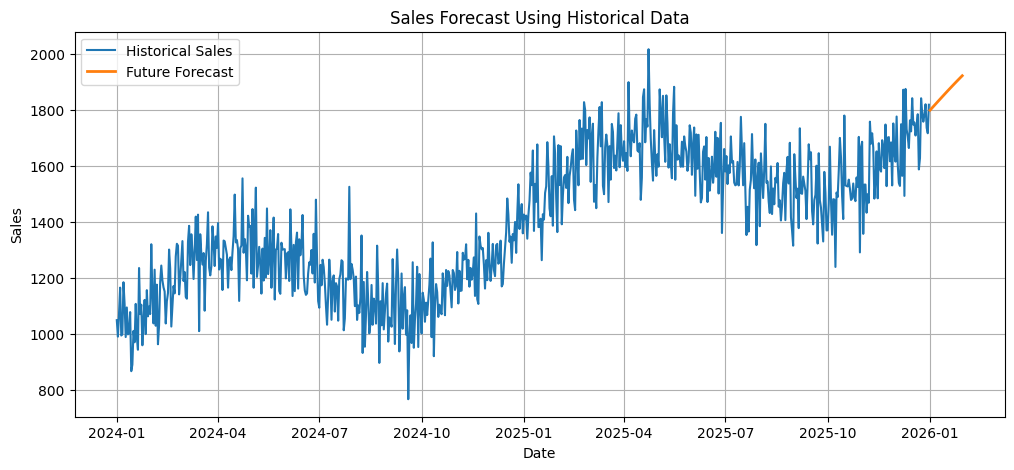

In [9]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Sales'],
    label='Historical Sales'
)

plt.plot(
    future['Date'],
    future['Predicted_Sales'],
    label='Future Forecast',
    linewidth=2
)

plt.title('Sales Forecast Using Historical Data')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()

plt.show()

Save the predictions

In [10]:
future[['Date', 'Predicted_Sales']].to_csv(
    'sales_forecast.csv',
    index=False
)

print("Forecast saved successfully!")

Forecast saved successfully!


Conclusion:

Historical sales data was cleaned and preprocessed to develop a predictive analytics model. A Linear Regression model with seasonal features was trained to predict future sales trends. The model was evaluated using MAE, RMSE and R² score. The final forecast demonstrates how historical data can be used to identify trends and support data-driven business decisions.